In [1]:
from pathlib import Path

In [2]:
path = Path("./../dl/4/goog.csv")

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv(path)
df

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400
...,...,...,...,...,...,...
56,3/13/2017,844.000000,848.684998,843.250000,845.539978,1149500
57,3/14/2017,843.640015,847.239990,840.799988,845.619995,779900
58,3/15/2017,847.590027,848.630005,840.770020,847.200012,1379600
59,3/16/2017,849.030029,850.849976,846.130005,848.780029,970400


In [5]:
df = df.iloc[:, 4:5]
df

,Close
0,794.200012
1,796.419983
2,794.559998
3,791.260010
4,789.909973
...,...
56,845.539978
57,845.619995
58,847.200012
59,848.780029


In [6]:
from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler()
df = sc.fit_transform(df)
df

array([[0.27870496],
       [0.30635093],
       [0.28318798],
       [0.24209223],
       [0.22527981],
       [0.24570341],
       [0.16475695],
       [0.13661236],
       [0.        ],
       [0.17833138],
       [0.18779601],
       [0.27646347],
       [0.42752207],
       [0.43374872],
       [0.41058501],
       [0.44943925],
       [0.43013678],
       [0.44906604],
       [0.4083435 ],
       [0.42652559],
       [0.37801975],
       [0.41344979],
       [0.5914072 ],
       [0.64819422],
       [0.79514303],
       [0.75130792],
       [0.64122041],
       [0.37982571],
       [0.31095859],
       [0.29732258],
       [0.33262797],
       [0.36948926],
       [0.36762172],
       [0.43773312],
       [0.4552927 ],
       [0.4699875 ],
       [0.52117039],
       [0.59053537],
       [0.60560414],
       [0.58729739],
       [0.6518054 ],
       [0.70049824],
       [0.74520517],
       [0.73399766],
       [0.74109613],
       [0.70759672],
       [0.71556701],
       [0.639

In [7]:
df

array([[0.27870496],
       [0.30635093],
       [0.28318798],
       [0.24209223],
       [0.22527981],
       [0.24570341],
       [0.16475695],
       [0.13661236],
       [0.        ],
       [0.17833138],
       [0.18779601],
       [0.27646347],
       [0.42752207],
       [0.43374872],
       [0.41058501],
       [0.44943925],
       [0.43013678],
       [0.44906604],
       [0.4083435 ],
       [0.42652559],
       [0.37801975],
       [0.41344979],
       [0.5914072 ],
       [0.64819422],
       [0.79514303],
       [0.75130792],
       [0.64122041],
       [0.37982571],
       [0.31095859],
       [0.29732258],
       [0.33262797],
       [0.36948926],
       [0.36762172],
       [0.43773312],
       [0.4552927 ],
       [0.4699875 ],
       [0.52117039],
       [0.59053537],
       [0.60560414],
       [0.58729739],
       [0.6518054 ],
       [0.70049824],
       [0.74520517],
       [0.73399766],
       [0.74109613],
       [0.70759672],
       [0.71556701],
       [0.639

In [8]:
import numpy as np

def createSeq(data, seqLen=3):
    x = []
    y = []

    for i in range(seqLen, len(data)):
        x.append(data[i - seqLen:i])
        y.append(data[i])

    return np.array(x), np.array(y)

In [9]:
x, y = createSeq(df)

In [10]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=False)

In [11]:
import tensorflow as tf
from tensorflow.keras import Sequential, layers

x_train.shape

(46, 3, 1)

In [12]:
model = Sequential([
    layers.Input(shape=(x_train.shape[1], 1)),
    layers.SimpleRNN(50, return_sequences=True),
    layers.Dropout(0.2),
    layers.SimpleRNN(50),
    layers.Dropout(0.2),
    layers.Dense(1)
])

In [13]:
model.compile(
    optimizer='adam',
    loss='mse',
)

In [14]:
history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32
)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.3321
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0789
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0881
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0759
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0853
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0591
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0511
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0620
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0442
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0520
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0497
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0529
Epoch 13/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0377
Epoch 14/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0452
Epoch 15/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0477
Epoch 16/50
2/2 ━━━━━━━━━━━━━━━━━━

In [15]:
y_pred = model.predict(x_test)
y_pred = sc.inverse_transform(y_pred)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


array([[824.42523],
       [828.5948 ],
       [823.5866 ],
       [823.10675],
       [824.87915],
       [828.68066],
       [831.07874],
       [834.11786],
       [836.5818 ],
       [836.72705],
       [837.08124],
       [838.50244]], dtype=float32)

In [16]:
y_test = sc.inverse_transform(y_test)

In [17]:
import matplotlib.pyplot as plt

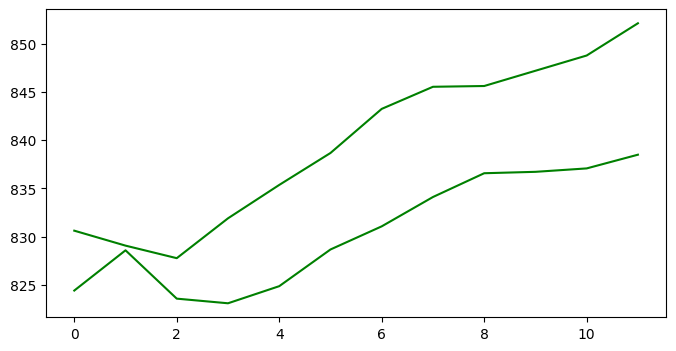

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(y_test, color='green')
plt.plot(y_pred, color='green')

In [ ]:
model2 = Sequential([
    layers.Input(shape=(x_train.shape[1], 1)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    lay